## Importing libraries

In [1]:
!pip install livelossplot
!pip install glob
import glob
import random, os
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dropout, Dense, Conv2D, MaxPool2D, Flatten, Reshape, BatchNormalization, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG19
from keras import backend
from livelossplot import PlotLossesKeras
import librosa
from librosa.display import specshow
import matplotlib.pyplot as plt
import IPython.display as ipd
from sklearn.metrics import confusion_matrix
import seaborn as sns

ERROR: Could not find a version that satisfies the requirement glob (from versions: none)
ERROR: No matching distribution found for glob


In [2]:
def setRandom():
    seed = 0
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.compat.v1.set_random_seed(seed)

## Data Collection and EDA

The dataset is stored at my Google Drive Repository due to the extinsive size. It can be accessed using the following URL:

https://drive.google.com/drive/folders/1f9XfO_Vd1sErp0KpUnnjF5CcgmcKh6wk?usp=sharing

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


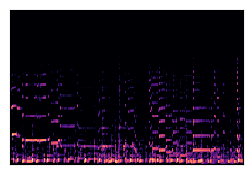

In [4]:
filePath = "/content/drive/MyDrive/Data/genres_original/jazz/jazz.00099.wav"

file, samplingRate = librosa.load(filePath)
example, _ = librosa.effects.trim(file)

hopLength = 512

spectrogram = librosa.power_to_db(librosa.feature.melspectrogram(y = example, sr = samplingRate, n_fft = 2048, hop_length = hopLength, n_mels = 128, power = 4.0), ref = np.max)

plt.figure(figsize = (3, 2))
librosa.display.specshow(spectrogram, sr = samplingRate, hop_length = hopLength, x_axis = "off", y_axis = "off")
ipd.Audio(example, rate = samplingRate)

In [5]:
source = "/content/drive/MyDrive/Data/images_original/"
genres = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

for genre in genres:
    path = os.path.join(source, genre)
    pngs = [i for i in os.listdir(path) if i[-4:] == ".png"]
    print(f"Size of {genre} dataset: {len(pngs)} files.")

Size of blues dataset: 100 files.
Size of classical dataset: 100 files.
Size of country dataset: 100 files.
Size of disco dataset: 100 files.
Size of hiphop dataset: 100 files.
Size of jazz dataset: 99 files.
Size of metal dataset: 100 files.
Size of pop dataset: 100 files.
Size of reggae dataset: 100 files.
Size of rock dataset: 100 files.


In [6]:
setRandom()
split = [80, 9, 10]
train, val, test = {}, {}, {}
trainLen, valLen, testLen = {}, {}, {}
dictionaries = [train, val, test]

for d in dictionaries:
    if d == train: num = slice(0, split[0])
    elif d == val: num = slice(split[0], split[0] + split[1])
    else: num = slice(split[0] + split[1], split[0] + split[1] + split[2])
    for genre in genres:
        path = os.path.join(source, genre)
        pngs = glob.glob(os.path.join(path, "*.png"))
        selected = pngs[num]
        d[genre] = selected

lenDictionaries = [{genre: len(d[genre]) for genre in genres} for d in dictionaries]

print(f"\033[1mTraining:\033[0m {lenDictionaries[0]}")
print(f"\033[1mValidation:\033[0m {lenDictionaries[1]}")
print(f"\033[1mTest:\033[0m {lenDictionaries[2]}")

Training: {'blues': 80, 'classical': 80, 'country': 80, 'disco': 80, 'hiphop': 80, 'jazz': 80, 'metal': 80, 'pop': 80, 'reggae': 80, 'rock': 80}
Validation: {'blues': 9, 'classical': 9, 'country': 9, 'disco': 9, 'hiphop': 9, 'jazz': 9, 'metal': 9, 'pop': 9, 'reggae': 9, 'rock': 9}
Test: {'blues': 10, 'classical': 10, 'country': 10, 'disco': 10, 'hiphop': 10, 'jazz': 10, 'metal': 10, 'pop': 10, 'reggae': 10, 'rock': 10}


In [7]:
batchSize = 32
genreMap = {
    "blues": 0,
    "classical": 1,
    "country": 2,
    "disco": 3,
    "hiphop": 4,
    "jazz": 5,
    "metal": 6,
    "pop": 7,
    "reggae": 8,
    "rock": 9
}
inverseGenreMap = {value: key for key, value in genreMap.items()}

def createDataset(d):
    imgSize = (288, 432) # define image and batch parameters
    imageList, labelList = [], [] # create lists to store images and labels

    for genre, paths in d.items():
        for path in paths:
            image = tf.cast(tf.image.resize(tf.image.decode_png(tf.io.read_file(path), channels = 3), imgSize), tf.float32) / 255.0 # normalise pixel values between 0 and 1 (preprocessing!)
            imageList.append(image)
            labelList.append(genreMap[genre]) # convert genre to its integer label

    dataset = tf.data.Dataset.from_tensor_slices((imageList, labelList)).shuffle(buffer_size=len(imageList)).batch(batchSize) # create and return tensorflow dataset
    return(dataset)

def prep(ds):
    out = (
        ds.map(lambda image, label: (tf.image.convert_image_dtype(image, tf.float32), label)) # modifies the image tensor's data type to floats
        .cache() # cache dataset elements in memory or on disk to speed up data loading
        .prefetch(buffer_size = tf.data.experimental.AUTOTUNE) # prefetch dataset elements in the background and automatically optimise data loading
    )
    return out # return the prepared and optimised dataset

training, validation, testing = prep(createDataset(train)), prep(createDataset(val)), prep(createDataset(test))
print("Datasets created.")

Datasets created.


Training Examples:


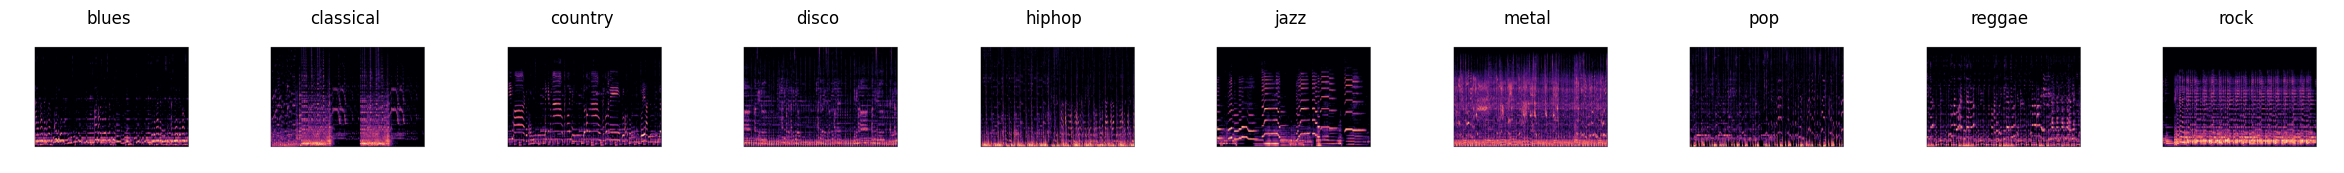

Validation Examples:


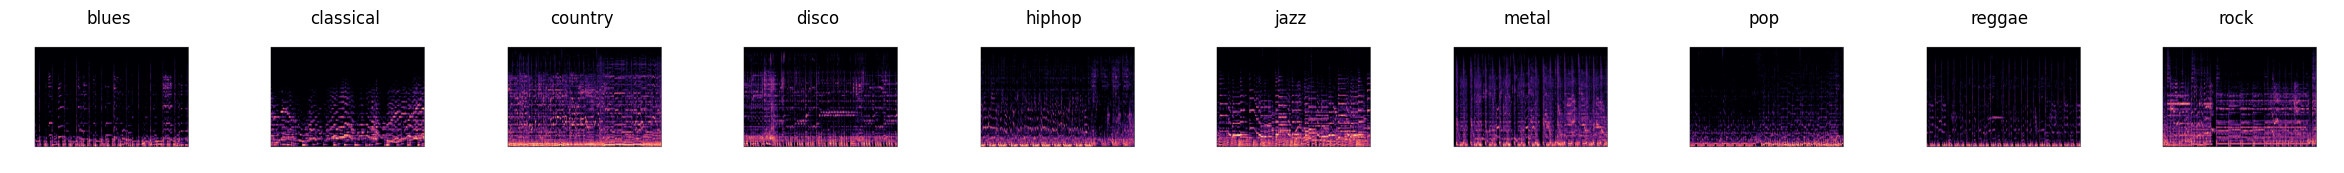

Testing Examples:


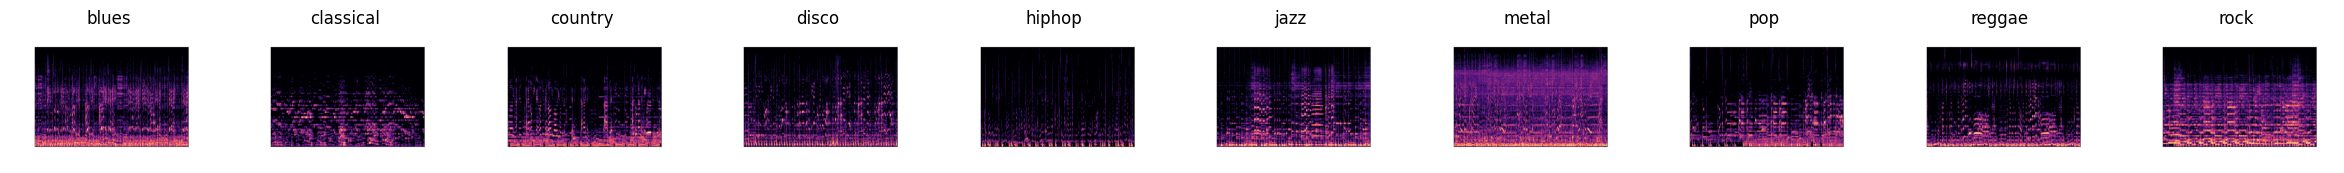

In [8]:
def view_dataset(dataset):
    genreExamples = {}  # dictionary to store examples for each label

    for images, labels in dataset:
        for image, label in zip(images, labels):
            label = int(label.numpy())  # convert label tensor to integer
            if label not in genreExamples:
                genreExamples[label] = image

        if len(genreExamples) == len(genres):
            break

    # display the randomly chosen examples
    plt.figure(figsize = (30, 20))
    for label, image in genreExamples.items():
        ax = plt.subplot(1, len(genres), label + 1)
        plt.imshow(image)
        plt.title(inverseGenreMap[label])
        plt.axis("off")
    plt.show()

print("\033[1mTraining Examples:\033[0m"); view_dataset(training) # shows a labelled example of a mel spectrogram from each genre from each dataset
print("\033[1mValidation Examples:\033[0m"); view_dataset(validation)
print("\033[1mTesting Examples:\033[0m"); view_dataset(testing)

In [9]:
inputShape = [288, 432, 3]

earlyStopping = EarlyStopping(
    min_delta = 0.001,
    patience = 20,
    restore_best_weights = True
)

## Model Development

In [10]:
from tensorflow.keras.applications import InceptionV3
baseModel = InceptionV3(input_shape = inputShape, weights = "imagenet", include_top = False, pooling = "avg")

for layer in baseModel.layers:
    layer.trainable = False

transfer = Sequential([
    baseModel,

    Flatten(),
    BatchNormalization(),
    Dense(512, activation = "relu"),
    Dropout(0.3),
    Dense(256, activation = "relu"),
    Dropout(0.3),
    Dense(128, activation = "relu"),
    Dropout(0.3),
    Dense(len(genres), activation = "softmax")
])

transfer.compile(optimizer = tf.keras.optimizers.SGD(lr = 0.0001), loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])
transfer.summary()

87910968/87910968 [==============================] - 0s 0us/step


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 2048)              21802784  
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 batch_normalization_94 (Ba  (None, 2048)              8192      
 tchNormalization)                                               
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                        

In [11]:
cnn = Sequential([
    BatchNormalization(input_shape = inputShape),

    Conv2D(32, (3, 3), activation = "relu"),
    MaxPool2D((2, 2)),

    Conv2D(64, (3, 3), activation = "relu"),
    MaxPool2D((2, 2)),

    Conv2D(128, (3, 3), activation = "relu"),
    MaxPool2D((2, 2)),

    Conv2D(256, (3, 3), activation = "relu"),
    MaxPool2D((2, 2)),

    Conv2D(512, (3, 3), activation = "relu"),
    MaxPool2D((2, 2)),

    Flatten(),
    Dense(1024, activation = "relu"),
    Dropout(0.5),
    Dense(512, activation = "relu"),
    Dropout(0.5),
    BatchNormalization(),
    Dense(len(genres), activation = "softmax")
])

cnn.compile(optimizer = tf.keras.optimizers.SGD(lr = 0.001), loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) # "sparse_categorical_crossentropy" because labels are integers
cnn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization_95 (Ba  (None, 288, 432, 3)       12        
 tchNormalization)                                               
                                                                 
 conv2d_94 (Conv2D)          (None, 286, 430, 32)      896       
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 143, 215, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_95 (Conv2D)          (None, 141, 213, 64)      18496     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 70, 106, 64)       0         
 g2D)                                                            
                                                      

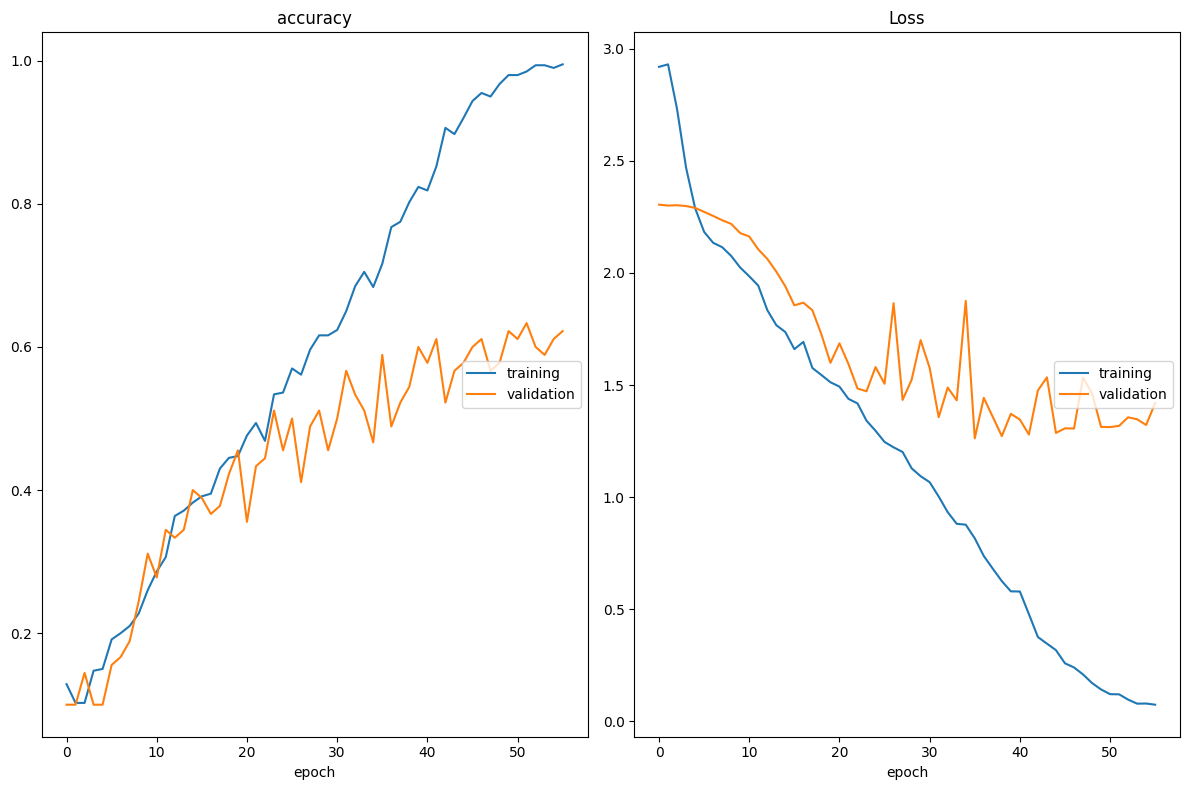

accuracy
	training         	 (min:    0.102, max:    0.995, cur:    0.995)
	validation       	 (min:    0.100, max:    0.633, cur:    0.622)
Loss
	training         	 (min:    0.073, max:    2.931, cur:    0.073)
	validation       	 (min:    1.262, max:    2.305, cur:    1.420)
25/25 [==============================] - 5s 183ms/step - loss: 0.0731 - accuracy: 0.9950 - val_loss: 1.4199 - val_accuracy: 0.6222


In [12]:
setRandom()
cnn.fit(training, validation_data = validation, batch_size = batchSize, epochs = 500, verbose = 1, callbacks = [earlyStopping, PlotLossesKeras()])

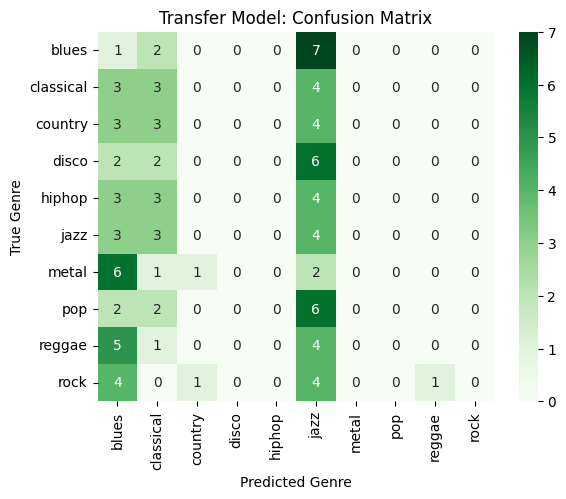

Transfer Model
Training Accuracy: 13.0% 
Train Loss: 2.3331

Validation Accuracy: 13.3333% 
Test Loss: 2.3244

Testing Accuracy: 8.0% 
Test Loss: 2.3357


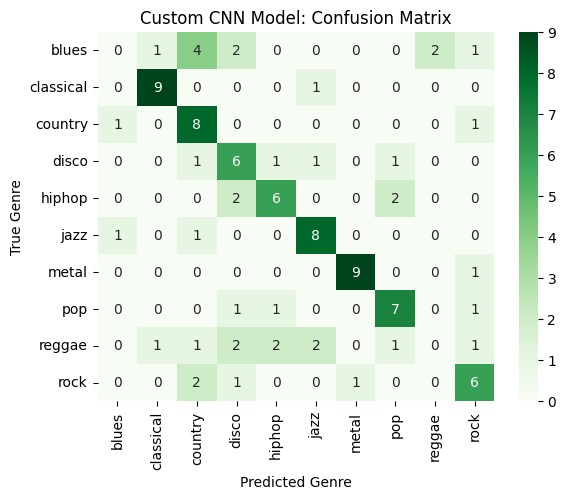

Custom CNN Model
Training Accuracy: 83.0% 
Train Loss: 0.5177

Validation Accuracy: 58.8889% 
Test Loss: 1.262

Testing Accuracy: 59.0% 
Test Loss: 1.1176


In [13]:
def confusionMatrix(model, name):
    trueLabels = np.concatenate([y for x, y in testing], axis = 0) # get the true labels from the testing dataset

    predictedLabels = np.argmax(model.predict(testing, verbose = 0), axis = 1) # get the predicted labels from the model

    matrix = confusion_matrix(trueLabels, predictedLabels) # create the confusion matrix

    plt.figure() # plot the confusion matrix using seaborn for the heatmap
    sns.heatmap(matrix, annot = True, cmap = "Greens", xticklabels = genres, yticklabels = genres)
    plt.xlabel("Predicted Genre")
    plt.ylabel("True Genre")
    plt.title(f"{name} Model: Confusion Matrix")
    plt.show()

    trainStats, valStats, testStats = model.evaluate(training, verbose = 0), model.evaluate(validation, verbose = 0), model.evaluate(testing, verbose = 0)
    print(f"\033[1m{name} Model\033[0m")
    print(f"Training Accuracy: {round(trainStats[1] * 100, 4)}% \nTrain Loss: {round(trainStats[0], 4)}\n")
    print(f"Validation Accuracy: {round(valStats[1] * 100, 4)}% \nTest Loss: {round(valStats[0], 4)}\n")
    print(f"Testing Accuracy: {round(testStats[1] * 100, 4)}% \nTest Loss: {round(testStats[0], 4)}")

confusionMatrix(transfer, "Transfer")
confusionMatrix(cnn, "Custom CNN")

## Testing

In [14]:
setRandom()
genre, paths = random.choice(list(test.items()))
path = paths[random.randint(0, len(paths) - 1)]
soundPath = f"{path[:-4]}.wav".replace("images_original", "genres_original")
soundPath = soundPath[:-9] + "." + soundPath[-9:]

image = tf.image.decode_png(tf.io.read_file(path), channels = 3)
image = tf.image.resize(image, inputShape[:2])
image = tf.cast(image, tf.float32) / 255.0
image = np.expand_dims(image, axis = 0)

predictions = cnn.predict(image)
predictedGenre = inverseGenreMap[np.argmax(predictions)]

print(f"\033[1mPredicted genre:\033[0m {predictedGenre}")
print(f"\033[1mActual genre:\033[0m {genre}")
print(f"\033[1mFilepath:\033[0m {soundPath[71:]}")
ipd.Audio(soundPath)

1/1 [==============================] - 1s 523ms/step
Predicted genre: metal
Actual genre: metal
Filepath: 


In [15]:
# Save the cnn model in Google Drive
cnn.save("/content/drive/MyDrive/cnn.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [16]:
# Save the model locally
import keras
model = globals()['cnn']
model.save('cnn.keras')